#### Visualisation

##### Importing Libraries and Loading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
from sklearn.manifold import TSNE
from pathlib import Path

In [2]:
project_root = Path.cwd().parent
processed_dir = project_root/'data'/'processed'
raw_dir = project_root/'data'/'raw'
figures_dir = project_root/'reports'/'figures'

In [3]:
features = pd.read_parquet(processed_dir/'station_anomaly.parquet')
features_scaled = pd.read_parquet(processed_dir/'station_features_scaled.parquet')
coords = pd.read_csv(raw_dir/'station_coordinates.csv')

##### t-SNE

In [4]:
tsne = TSNE(n_components=2, perplexity=30, random_state=69, init='pca')
embedding = tsne.fit_transform(features_scaled.values)

In [5]:
# 2-D coordinates per station

features['tsne_x'] = embedding[:, 0]
features['tsne_y'] = embedding[:, 1]

In [7]:
# Cluster names

archetypes = features['archetype'].unique()

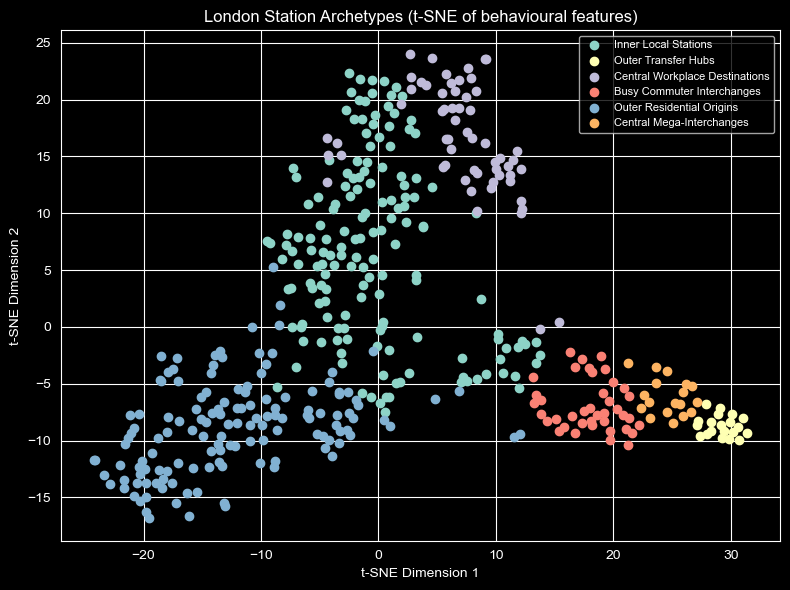

In [17]:
# Plotting each Archetype as their own colored group

plt.figure(figsize=(8, 6))
for name in archetypes:
    subset = features[features['archetype'] == name]
    plt.scatter(subset['tsne_x'], subset['tsne_y'], label=name)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('London Station Archetypes (t-SNE of behavioural features)')
plt.legend(fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir/'tsne_archetypes.png', dpi=150)

plt.show()

##### London Map

In [18]:
coords = coords.set_index('MasterNLC')[['Latitude', 'Longitude']]

In [19]:
features = features.join(coords)

In [21]:
features.head()

,log_total_weekday,early_share,eve_share,late_share,peakness,am_asym,pm_asym,weekend_shift,weekend_ratio,lines_served,...,cluster_dbscan,station_name,archetype,anomaly,anomaly_score,dbscan_noise,tsne_x,tsne_y,Latitude,Longitude
nlc,,,,,,,,,,,,,,,,,,,,,
750,7.760586,0.077621,0.094472,0.041111,0.030217,0.139383,-0.006690,0.213420,0.783216,1,...,0,Abbey Road,Inner Local Stations,1,0.162122,False,-1.667466,13.186955,51.533,0.004
1404,7.923830,0.071789,0.080898,0.027622,0.036185,0.116857,-0.139332,0.267944,0.725684,1,...,0,Acton Central,Inner Local Stations,1,0.179367,False,-5.644836,3.381376,51.509,-0.263
3000,8.666488,0.072965,0.052739,0.012879,0.043083,0.420971,-0.182355,0.291676,0.847376,1,...,0,Acton Main Line,Inner Local Stations,1,0.189258,False,-8.676973,-5.285949,51.517,-0.268
500,9.014619,0.054701,0.059517,0.020899,0.040084,0.274624,-0.098968,0.242156,0.812725,2,...,-1,Acton Town,Outer Transfer Hubs,1,0.108612,True,27.945915,-9.405088,51.503,-0.280
502,9.483445,0.018862,0.125731,0.043576,0.049968,-0.556020,0.334524,0.255896,0.527519,2,...,0,Aldgate,Central Workplace Destinations,1,0.084858,False,9.602420,12.253036,51.514,-0.076


In [24]:
features['archetype'].value_counts()

archetype
Inner Local Stations              157
Outer Residential Origins         138
Central Workplace Destinations     59
Busy Commuter Interchanges         40
Outer Transfer Hubs                20
Central Mega-Interchanges          18
Name: count, dtype: int64

In [25]:
# Color Palette per Archetype

palette = {
     'Outer Residential Origins': 'green',
    'Central Mega-Interchanges': 'red',
    'Inner Local Stations': 'blue',
    'Busy Commuter Interchanges': 'purple',
    'Central Workplace Destinations': 'orange',
    'Outer Transfer Hubs': 'black',
}

In [57]:
station_map = folium.Map(location=[51.509, -0.126], zoom_start=10.5, tiles='cartodbpositron')

for nlc, row in features.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color=palette.get(row['archetype']),
        tooltip=f"{row['station_name']} - {row['archetype']}",
    ).add_to(station_map)

station_map

In [58]:
# Saving
features.to_parquet(processed_dir/'station_final.parquet')
station_map.save(str(figures_dir/'station_map.html'))